# M5A2 - Reconhecimento de Texto

Na prática de hoje vamos utilizar um modelo na tarefa de reconhecimento de texto.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Utilizar Modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
%pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 7.9 MB/s  0:00:05m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 6.0 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [easyocr]9/10 [easyocr]mage]-headless]
Note: you may need to restart the kernel to use updated packages.


## Introdução

Importar as bibliotecas e visualizar imagens

In [11]:
import easyocr
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

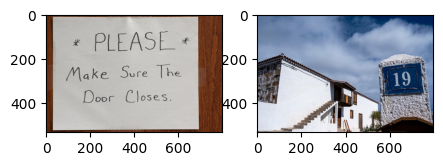

In [3]:
eng_image = Image.open("./images/eng.jpeg")
num_image = Image.open("./images/num.jpeg")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 5))
axes[0].imshow(eng_image)
axes[1].imshow(num_image)


## Carregar Modelo e Utilizar Modelo

In [4]:
reader = easyocr.Reader(["en"]) # Carrega o modelo de inglês para a memória.

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

[([[np.int32(203), np.int32(60)], [np.int32(587), np.int32(60)], [np.int32(587), np.int32(189)], [np.int32(203), np.int32(189)]], 'PLEASE', np.float64(0.9943932372797761)), ([[np.int32(91), np.int32(229)], [np.int32(293), np.int32(229)], [np.int32(293), np.int32(313)], [np.int32(91), np.int32(313)]], 'Make', np.float64(0.9997633099555969)), ([[np.int32(333), np.int32(229)], [np.int32(469), np.int32(229)], [np.int32(469), np.int32(295)], [np.int32(333), np.int32(295)]], 'Sure', np.float64(0.9992990493774414)), ([[np.int32(494), np.int32(222)], [np.int32(620), np.int32(222)], [np.int32(620), np.int32(296)], [np.int32(494), np.int32(296)]], 'The', np.float64(0.9913306961180851)), ([[np.int32(164), np.int32(336)], [np.int32(320), np.int32(336)], [np.int32(320), np.int32(410)], [np.int32(164), np.int32(410)]], 'Door', np.float64(0.9977179765701294)), ([[np.int32(354), np.int32(336)], [np.int32(572), np.int32(336)], [np.int32(572), np.int32(410)], [np.int32(354), np.int32(410)]], 'Closes.', 

/Users/joseph-cbp/Documents/Visão Computacional/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


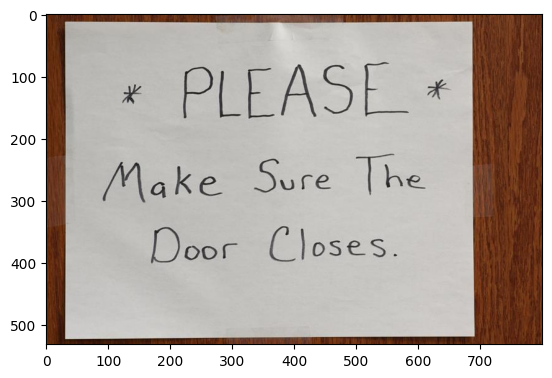

In [22]:
plt.imshow(eng_image)
result = reader.readtext("./images/eng.jpeg", detail=1)
print(result)

[([[np.int32(607), np.int32(249)], [np.int32(707), np.int32(249)], [np.int32(707), np.int32(337)], [np.int32(607), np.int32(337)]], '19', np.float64(0.9679082277422948))]


/Users/joseph-cbp/Documents/Visão Computacional/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


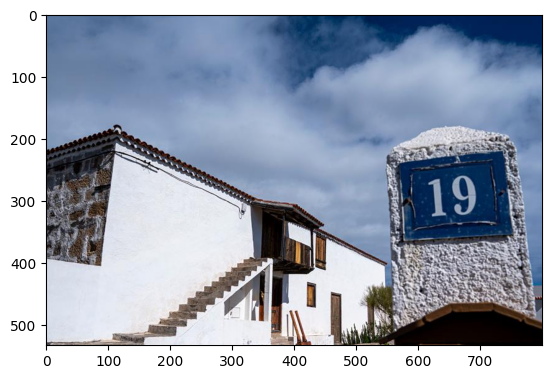

In [8]:
plt.imshow(num_image)
result = reader.readtext("./images/num.jpeg", detail=1)
print(result)

## Próximos Passos e Referências

Nas próximas práticas vamos continuar trabalhando com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/JaidedAI/EasyOCR
- https://www.jaided.ai/easyocr/
- https://huggingface.co
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente alterar as imagens utilizadas nos testes.
- [ ] Altere o parâmetro `detail` para `1` e tente desenhar as informações de bounding box na imagem.

Texto: PLEASE
Confiança: 99.44%

Texto: Make
Confiança: 99.98%

Texto: Sure
Confiança: 99.93%

Texto: The
Confiança: 99.13%

Texto: Door
Confiança: 99.77%

Texto: Closes.
Confiança: 97.48%



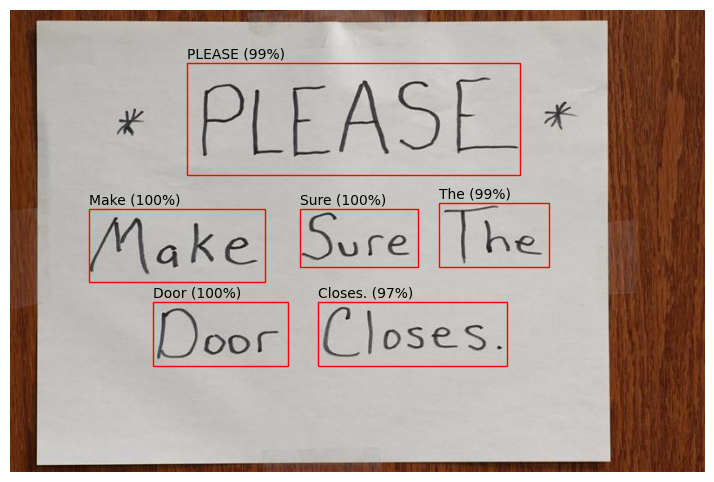

In [24]:
_, ax = plt.subplots(figsize=(12, 6))
ax.imshow(eng_image)
# print(result)
for bbox, text, conf in result:
    print(f"Texto: {text}")
    print(f"Confiança: {conf:.2%}")
    print()
    if conf < 0.0:
        continue
    pts = np.array(bbox, dtype=np.float32)
    box = patches.Polygon(
        pts,
        closed=True,
        edgecolor= 'red',
        facecolor='none',

    )
    ax.add_patch(box)
    tl_x, tl_y = pts[0]
    ax.text(
        tl_x, tl_y - 5,
        f"{text} ({conf:.0%})"
    )
    ax.axis('off')
    